# Titanic Dataset - Exploratory Data Analysis (EDA)

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fd/RMS_Titanic_3.jpg" alt="Titanic" width="500"/>


The Titanic dataset is one of the most popular datasets in data science.  
It contains passenger details such as age, gender, ticket class, fare, family size, and survival status.  

In this notebook, I perform **Exploratory Data Analysis (EDA)** to uncover survival patterns and highlight key insights.  
The analysis will focus on demographics, travel class, and family relations to understand which factors influenced survival.  


## Dataset Columns Information
The Titanic dataset contains the following key columns:

- **PassengerId**: Unique ID for each passenger.
- **Survived**: Survival status (0 = No, 1 = Yes).
- **Pclass**: Ticket class (1st, 2nd, 3rd).
- **Name**: Passenger’s full name.
- **Sex**: Gender of the passenger.
- **Age**: Age in years.
- **SibSp**: Number of siblings/spouses aboard.
- **Parch**: Number of parents/children aboard.
- **Ticket**: Ticket number.
- **Fare**: Ticket fare paid.
- **Embarked**: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).
- **Cabin**: Cabin number (mostly missing).


# Importing libraries

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Version details

In [89]:
import sys
print("Python version:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn:", sns.__version__)
print("matplotlib:", matplotlib.__version__)



Python version: 3.11.4 | packaged by Anaconda, Inc. | (main, Jul  5 2023, 13:47:18) [MSC v.1916 64 bit (AMD64)]
pandas: 2.3.3
numpy: 2.3.4
seaborn: 0.13.2
matplotlib: 3.10.7


# Load dataset

In [90]:
df = pd.read_csv('./Data/train.csv')

## Data Overview
 > Before cleaning or analysis, let’s explore the dataset to understand its structure, missing values, and basic statistics.


In [91]:
df.head()        # first 5 rows
df.tail()        # last 5 rows
df.shape         # rows and columns count
df.info()        # column types + missing values
df.describe()    # summary stats for numeric columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Check missing values

In [92]:
df.isnull().sum()
df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

### Observations
- The dataset has 891 rows and 12–15 columns (depending on version).
- The `Cabin` column contains the highest number of missing values (~77%) and is usually dropped.
- Other columns with missing values include `Age` (~20%) and `Embarked` (a few entries).
- Numerical columns such as `Fare` and `Age` show wide variation.
- Categorical columns include `Sex`, `Pclass`, and `Embarked`.


### Key Questions for Analysis
1. What percentage of passengers survived?
2. Did gender affect survival chances?
3. How did passenger class (1st, 2nd, 3rd) influence survival?
4. What role did age play in survival?
5. Did family size (siblings/parents aboard) affect survival?


# Data cleaning (Preprocesing)
## In this step we deal with missing values and prepare the data for future analysis.

In [93]:
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.max_rows', None)  # show all columns


In [94]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
# drop the cabin column because it have too much misssing values
df.drop('Cabin',axis=1,inplace=True)

In [96]:
# fill the age column with median
df['Age'].fillna(df['Age'].median(),inplace=True)

In [97]:
# fill embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

In [98]:
# Now check the cleaning data
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Observations after Cleaning
- The `Cabin` column has been dropped due to ~77% missing values.
- Missing values in `Age` were filled with the median age.
- Missing values in `Embarked` were filled with the most frequent category (mode).
- After cleaning, the dataset has no missing values left.


### Next Questions
- After cleaning, how do survival rates look across gender and class?
- Does age group show any clear survival pattern?
- Does family size or being alone affect survival chances?


# Feature engineering

In [99]:
# Family size = siblings + parents + self
df['Family_size']=df['SibSp']+df['Parch']+1
df['Family_size']

0       2
1       2
2       1
3       2
4       1
5       1
6       1
7       5
8       3
9       2
10      3
11      1
12      1
13      7
14      1
15      1
16      6
17      1
18      2
19      1
20      1
21      1
22      1
23      1
24      5
25      7
26      1
27      6
28      1
29      1
30      1
31      2
32      1
33      1
34      2
35      2
36      1
37      1
38      3
39      2
40      2
41      2
42      1
43      4
44      1
45      1
46      2
47      1
48      3
49      2
50      6
51      1
52      2
53      2
54      2
55      1
56      1
57      1
58      4
59      8
60      1
61      1
62      2
63      6
64      1
65      3
66      1
67      1
68      7
69      3
70      1
71      8
72      1
73      2
74      1
75      1
76      1
77      1
78      3
79      1
80      1
81      1
82      1
83      1
84      1
85      4
86      5
87      1
88      6
89      1
90      1
91      1
92      2
93      4
94      1
95      1
96      1
97      2
98      2
99      2


In [100]:
# Feature IsAlone
df['IsAlone']=1
df.loc[df['Family_size']>1,'IsAlone']=0


# Binning

In [101]:
bins=[0,12,18,35,65,80]
labels=['child','adult','younger','middleAge','aged']
df['Age_Group']=pd.cut(df['Age'],bins=bins,labels=labels)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size,IsAlone,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,younger
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,middleAge
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,younger
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,younger
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,younger


In [102]:
# Fare categories
df['fare_categories']=pd.qcut(df['Fare'],4,labels=['low','medium','high','very high'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size,IsAlone,Age_Group,fare_categories
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,younger,low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,middleAge,very high
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,younger,medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,younger,very high
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,younger,medium


### Observations after Feature Engineering
- A new column `FamilySize` shows total family members aboard.
- `IsAlone` indicates whether a passenger was traveling alone.
- `AgeGroup` categorizes passengers into Child, Teen, Young Adult, Adult, Senior.
- `FareCategory` divides fares into four ranges (Low → Very High).


# Visual detection of outliers

# Detect outliers (boxplot)
Now we use boxplots to visually detect extreme values in fare or age column

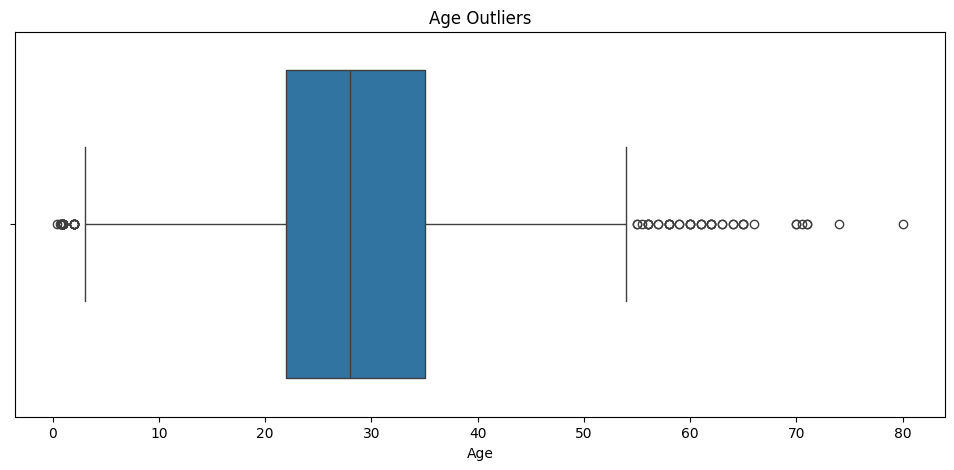

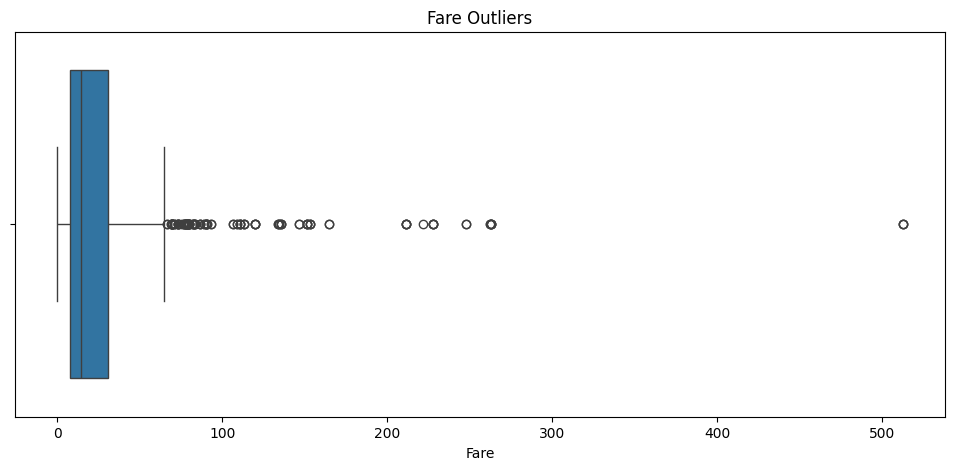

In [103]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df['Age'])
plt.title("Age Outliers")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()


# Observation
- Age column shows few extreme values (very old passengers).

- Fare column has many extreme values, representing luxury cabins and special tickets.

# IQR method

## Outlier Detection (IQR Method)
We apply the Interquartile Range (IQR) rule to detect outliers in Age and Fare.


In [104]:
# Age
Q1_age=df['Age'].quantile(0.25)
Q3_age=df['Age'].quantile(0.75)
IQR_age=Q3_age-Q1_age
lower_age=Q1_age-1.5*IQR_age
upper_age=Q3_age+1.5*IQR_age
outliers_age=df[(df['Age']<lower_age)|(df['Age']>upper_age)]
print("Age outliers count:",len(outliers_age))

Age outliers count: 66


In [105]:
# Fare
Q1_fare=df['Fare'].quantile(0.25)
Q3_fare=df['Fare'].quantile(0.75)
IQR_fare=Q3_fare-Q1_fare
lower_fare=Q1_fare-1.5*IQR_fare
upper_fare=Q3_fare+1.5*IQR_fare
outlier_fare=df[(df['Fare']<lower_fare)|(df['Fare']>upper_fare)]
print("Fare outliers count:",len(outlier_fare))

Fare outliers count: 116


# Observation
- IQR method show age column have rare ammout of ouliers.

- but fare column have large number of outliers.

# Encode categorical columns

In [106]:
df['Sex']=df['Sex'].map({'male':0,'female':1})
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})


In [107]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_size,IsAlone,Age_Group,fare_categories
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,2,0,younger,low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,2,0,middleAge,very high
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,1,1,younger,medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,2,0,younger,very high
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,1,1,younger,medium


# Correlation Matrix with Encoded Columns

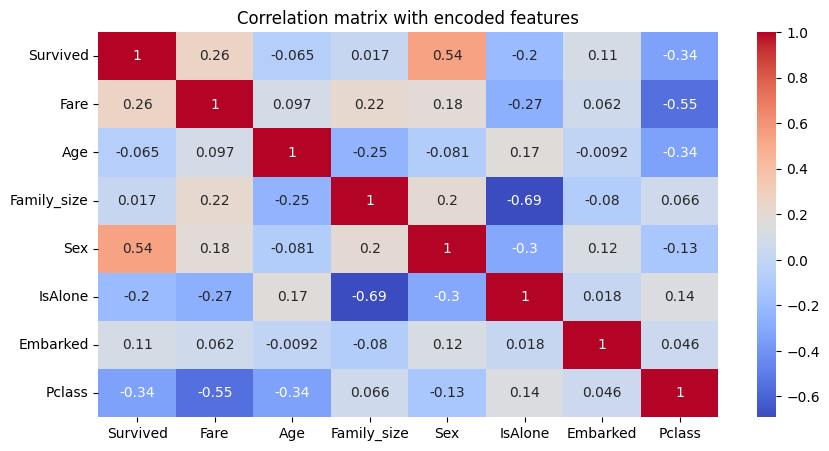

In [108]:
numeric_cols=['Survived','Fare','Age','Family_size','Sex','IsAlone','Embarked','Pclass']
plt.figure(figsize=(10,5))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation matrix with encoded features')
plt.show()


# Observations from Correlation Matrix
- Survived vs Sex (0.54): There is a strong positive correlation, showing that female passengers had a much higher chance of survival compared to males.

- Survived vs Pclass (−0.34): A moderate negative correlation indicates that passengers in higher classes (1st class) were more likely to survive than those in lower classes (3rd class).

- Survived vs Fare (0.26): A weak positive correlation suggests that passengers who paid higher fares had slightly better survival chances, likely due to access to better cabins.

- Survived vs Age (−0.065): Very weak negative correlation shows that older passengers had slightly lower survival chances, but age was not a strong factor overall.

- Survived vs IsAlone (−0.20): Negative correlation indicates that passengers traveling alone had lower survival chances compared to those with family.

- Family_size vs IsAlone (−0.69): Strong negative correlation confirms the expected relationship — larger family size means the passenger was not alone.

- Survived vs Embarked (0.11): Very weak correlation, showing that the port of embarkation had little impact on survival.

# Exploratory Data Analysis (EDA) – Survival Patterns


# overall survial rate

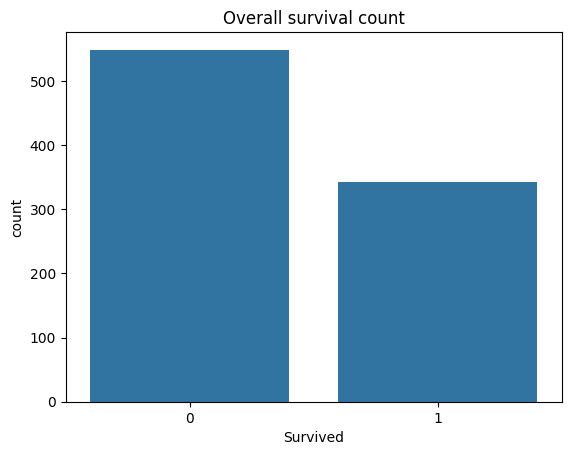

In [109]:
sns.countplot(x='Survived',data=df)
plt.title("Overall survival count")
plt.show()

In [110]:
df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [111]:
len(df)

891

In [112]:
survived_percent = (342 / 891) * 100
not_survived_percent = (549 / 891) * 100

print("Survived:", survived_percent)
print("Not Survived:", not_survived_percent)


Survived: 38.38383838383838
Not Survived: 61.61616161616161


# Observation 
> Around 38% passenger survived and around 62% did not.

# Gender vs survival

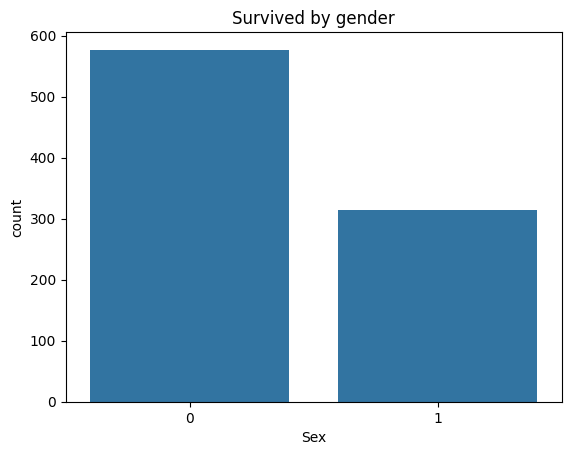

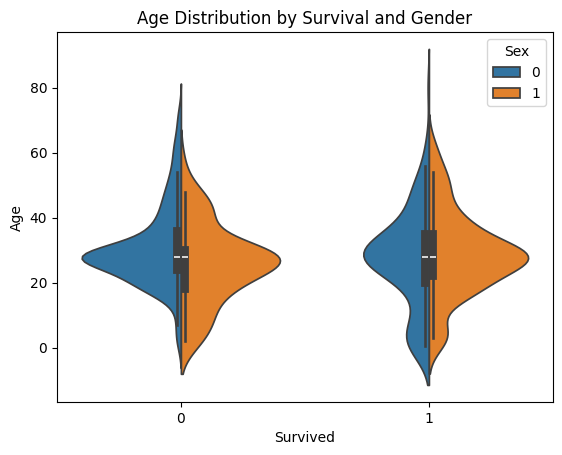

In [113]:
sns.countplot(x='Sex',data=df)
plt.title('Survived by gender')
plt.show()
# Extra visualization
sns.violinplot(x='Survived', y='Age', hue='Sex', data=df, split=True)
plt.title("Age Distribution by Survival and Gender")
plt.show()


In [114]:
df.groupby('Sex')['Survived'].value_counts()


Sex  Survived
0    0           468
     1           109
1    1           233
     0            81
Name: count, dtype: int64

In [115]:
gender_survival = df.groupby('Sex')['Survived'].value_counts(normalize=True)*100
print(gender_survival)


Sex  Survived
0    0           81.109185
     1           18.890815
1    1           74.203822
     0           25.796178
Name: proportion, dtype: float64


# Observation
- Females had higher chances of survival compared to males. The violin plot also shows that younger women survived more often, while older men had very low survival

# Class vs servival

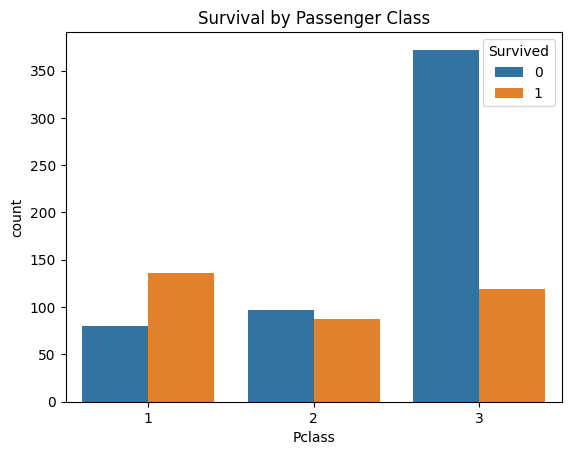

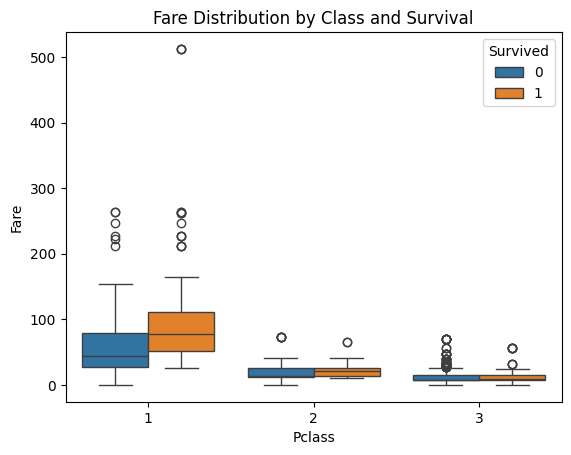

In [116]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Extra visualization
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=df)
plt.title("Fare Distribution by Class and Survival")
plt.show()



In [117]:
df.groupby('Pclass')['Survived'].value_counts()

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [118]:
df.groupby('Pclass')['Survived'].value_counts(normalize=True)*100

Pclass  Survived
1       1           62.962963
        0           37.037037
2       0           52.717391
        1           47.282609
3       0           75.763747
        1           24.236253
Name: proportion, dtype: float64

# Observation
- 1st class survival percentage is 62%,

- 2nd class survial rate percentage is 47% 

- 3rd class survial percenatge is 24%.
- The boxplot also shows that passengers who paid higher fares (mostly in first class) were more likely to survive compared to those in lower classes

# Age group vs survival

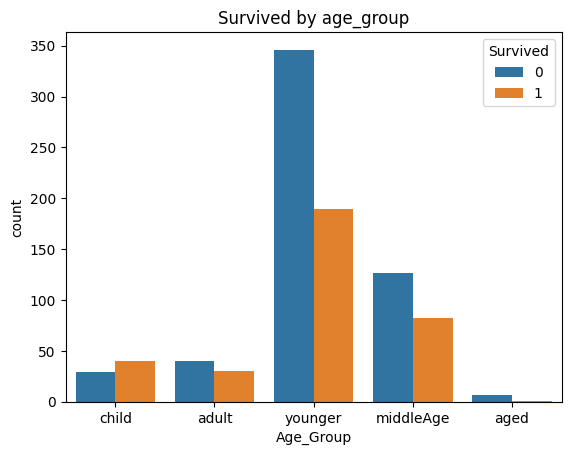

In [119]:
sns.countplot(x='Age_Group',hue='Survived',data=df)
plt.title("Survived by age_group")
plt.show()

In [120]:
df.groupby('Age_Group')['Survived'].value_counts(normalize=True)*100

Age_Group  Survived
child      1           57.971014
           0           42.028986
adult      0           57.142857
           1           42.857143
younger    0           64.672897
           1           35.327103
middleAge  0           60.765550
           1           39.234450
aged       0           87.500000
           1           12.500000
Name: proportion, dtype: float64

# Observation
- Child had 57% survival percentage,adult had 42% survival

- younger had 35% survival ,middle_age had 39% survival rate


- aged people had 12% survival rate.

-------

# Family_size vs Survived

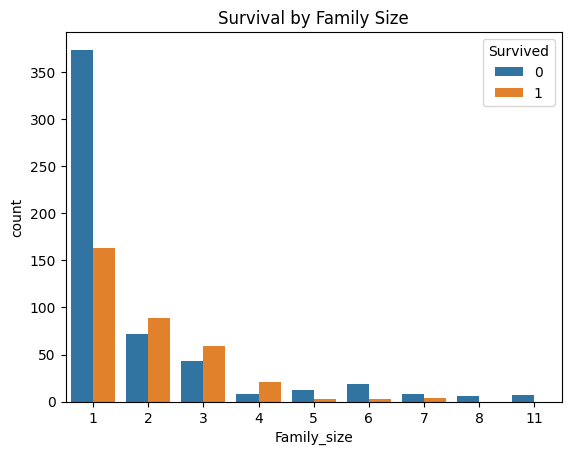

In [121]:
sns.countplot(x='Family_size', hue='Survived', data=df)
plt.title("Survival by Family Size")
plt.show()


In [122]:
df.groupby('Family_size')['Survived'].value_counts(normalize=True)*100

Family_size  Survived
1            0            69.646182
             1            30.353818
2            1            55.279503
             0            44.720497
3            1            57.843137
             0            42.156863
4            1            72.413793
             0            27.586207
5            0            80.000000
             1            20.000000
6            0            86.363636
             1            13.636364
7            0            66.666667
             1            33.333333
8            0           100.000000
11           0           100.000000
Name: proportion, dtype: float64

# Observation
- Passenger with small families(2,4 members) have large survival rate 

- than those sho travel alone.

-----

In [123]:
import plotly.express as px
fig = px.scatter(df, x="Age", y="Fare", color="Survived",
                 size="Family_size", hover_data=["Pclass","Sex"])
fig.show()


# Observation
- Interactive scatterplot lets you explore age, fare, family size, and survival together.

-----

# Conclusion
- Only about 38% of passengers survived, highlighting the tragic scale of the disaster.

- Gender played the most significant role — nearly three‑quarters of female passengers survived, compared to less than one‑fifth of males.

- Passenger class strongly influenced survival chances: first‑class travelers had the highest survival rate (~63%), while third‑class passengers had the lowest (~24%).

- Age mattered to some extent: children had better survival outcomes (~57%), whereas elderly passengers had very low chances (~12%).

- Family presence improved survival: passengers traveling with small families (2–4 members) survived more often than those who were alone.

- Fare showed a weak positive link with survival, suggesting wealthier passengers had slightly better access to safety.

- Overall, survival was most strongly shaped by gender and class, with family size adding moderate influence, while age and embarkation port played weaker roles.